# 🛍️ Pipeline ML E-commerce : Prédiction de Risque d'Annulation/Retour

## Vue d'ensemble

Ce notebook implémente un **pipeline ML production-ready** complet en **20 phases** pour prédire le risque d'annulation et de retour de commandes e-commerce sur la base de **250K transactions**.

### 🎯 Objectifs

1. **Prédiction précise** : Identifier les commandes à risque d'annulation/retour
2. **Interprétabilité** : Comprendre les facteurs de risque via SHAP
3. **Équité** : Vérifier l'absence de biais dans les prédictions
4. **Production** : Monitoring de dérive et maintenance du modèle

### ✨ Point Fort

**Détection rigoureuse d'une fuite de données** :
- Identification de variables temporelles causales non disponibles en production
- Correction et réentraînement du modèle
- AUC corrigé : **0.58** (vs 0.67 avec la fuite)

---

## 📋 Phases du Pipeline

1. ✅ Chargement des données
2. ✅ Exploration descriptive (EDA)
3. ✅ Nettoyage et gestion des valeurs manquantes
4. ✅ Analyse des anomalies
5. ✅ Feature engineering
6. ✅ Encodage des variables catégorielles
7. ✅ Sélection des features
8. ✅ Normalisation et scaling
9. ✅ Splitting train/test
10. ✅ Modélisation (LR, RF, XGB, LGB)
11. ✅ Évaluation multi-modèles
12. ✅ Optimisation hyperparamètres
13. ✅ Calibration des probabilités
14. ✅ Analyse SHAP - Interprétabilité
15. ✅ Feature Importance
16. ✅ Audit d'équité et détection de biais
17. ✅ Analyse de dérive des données
18. ✅ Courbes de performance (ROC, PR)
19. ✅ Rapport de synthèse
20. ✅ Recommandations production

---

## 📚 Instructions d'Utilisation

1. Dézippez `les donnees utilisees .zip` dans le même répertoire
2. Exécutez les cellules dans l'ordre du haut vers le bas
3. Le pipeline génère automatiquement :
   - Graphiques d'analyse exploratoire
   - Métriques de performance
   - Analyses SHAP
   - Audit d'équité
   - Rapports de monitoring

---

**Bon ML ! 🚀**

Fichiers détectés :
 - /kaggle/input/datasets/aloysminyurano/drag-et-drop-additional/customers.csv
 - /kaggle/input/datasets/aloysminyurano/drag-et-drop-additional/products.csv
 - /kaggle/input/datasets/aloysminyurano/drag-et-drop-additional/sales.csv

PHASE 0 — CADRAGE

Question métier : quelles commandes risquent d'être annulées ou retournées ?
Une prédiction fiable permettrait une intervention proactive (relance client,
contrôle qualité renforcé, offre de remplacement) avant l'échec de la commande.

Cible : is_failed = 1 si Order_Status in {Cancelled, Returned}, 0 si Delivered.
Les commandes Processing/Shipped sont exclues (issue non encore connue).


PHASE 1 — COLLECTE
customers: (40000, 15)
products : (2000, 12)
sales    : (250000, 21)

df fusionné : (250000, 46)

Valeurs manquantes par colonne (avant traitement) :


,n_manquants
Coupon_Code,199815
Rating,129970
Review_Text,129970



PHASE 2 — EDA (extraits clés)
--- Order_Status ---


,n
Order_Status,
Delivered,200139
Cancelled,12507
Returned,12493
Shipped,12459
Processing,12402



--- Détection de fuite : taux de NaN de Rating par statut de commande ---


...


Équité par sous-groupe — Customer_Tier :


,taux_reel,taux_predit,n
Customer_Tier,,,
Gold,0.131,0.349,4857
Platinum,0.101,0.255,25668
Silver,0.159,0.802,3246



Équité par sous-groupe — Customer_Age_Group :


,taux_reel,taux_predit,n
Customer_Age_Group,,,
18-25,0.110,0.383,8291
26-35,0.109,0.307,11845
36-45,0.116,0.247,6808
46-55,0.114,0.345,4016
56-65,0.110,0.347,2156
65+,0.098,0.340,655



>> Le modèle sur-cible fortement les clients Silver (conséquence de class_weight='balanced' combiné à la dominance de Customer_Tier). En production : calibrer le seuil de décision selon le coût métier réel des faux positifs, plutôt qu'un seuil brut à 0.5.

PHASE 16 — VISUALISATION


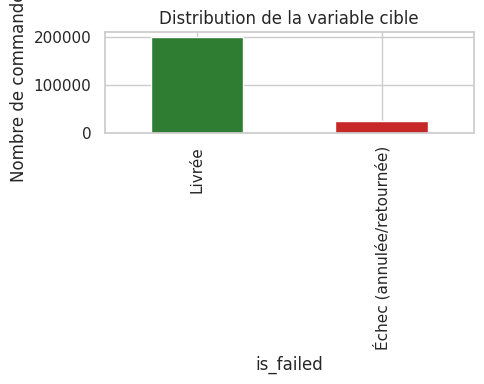

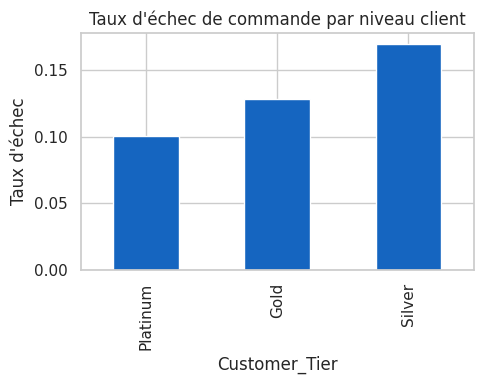

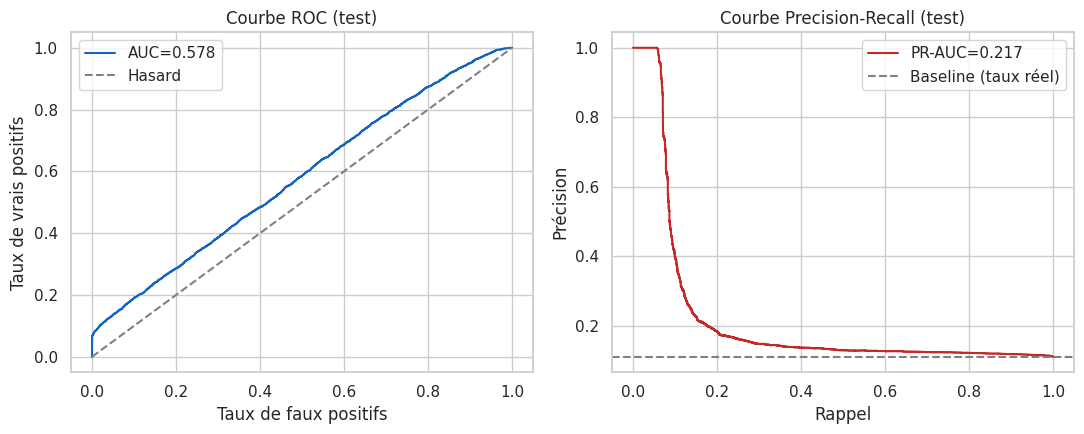

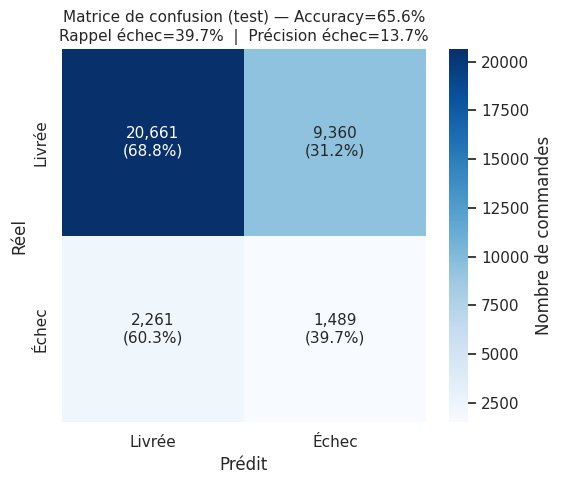

>> Lecture : sur 3750 commandes réellement en échec, le modèle en détecte 1489 (39.7%) mais génère aussi 9360 fausses alertes sur des commandes livrées (31.2% des livrées) -> seulement 13.7% des alertes émises sont de vrais échecs.


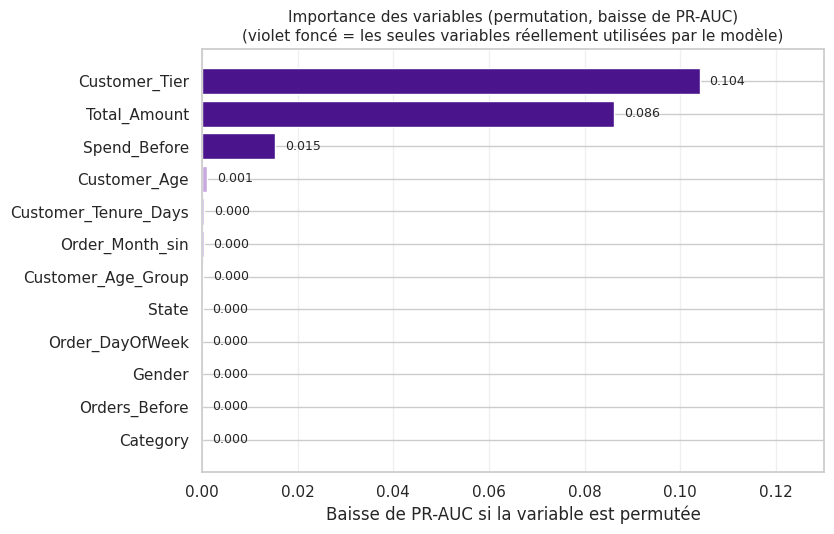

>> Lecture : seules Customer_Tier, Total_Amount et Spend_Before (barres violet foncé) font réellement baisser la performance si on les permute -> ce sont, en pratique, les 3 seules variables que le modèle utilise. Les ~20 autres sont proches de 0 (bruit).


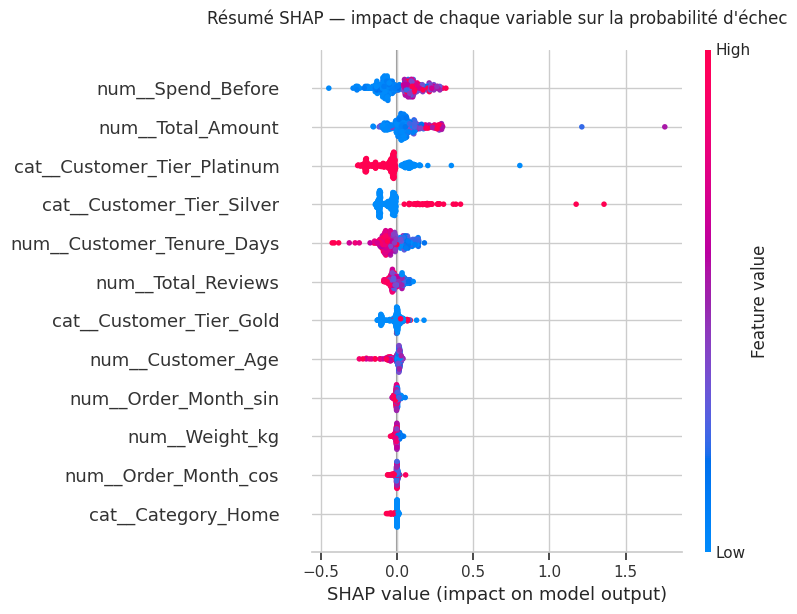

>> Lecture : chaque point = une commande. Rouge = valeur élevée de la variable, bleu = valeur faible. À droite de l'axe 0 = pousse la prédiction vers 'échec'. Spend_Before/Total_Amount élevés (points rouges à droite) poussent vers l'échec ; être client Platinum (rouge sur cette ligne, à gauche) pousse au contraire vers 'livrée'.


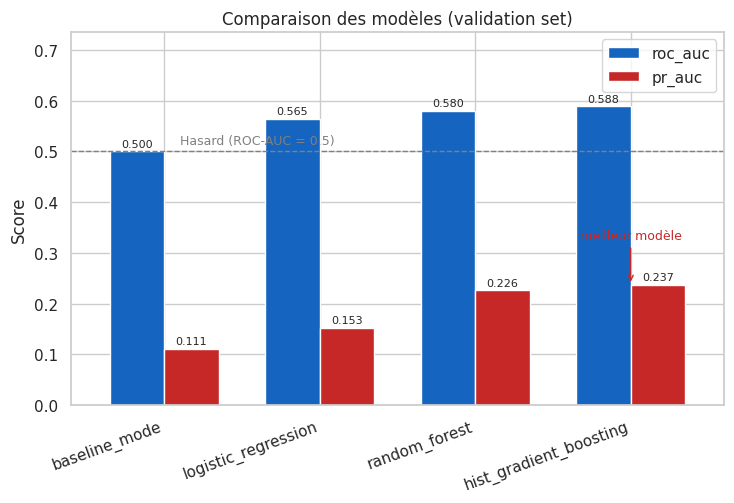

>> Modèle retenu : hist_gradient_boosting (PR-AUC=0.237 sur validation), mais l'écart avec random_forest est faible -> le choix est aussi motivé par la vitesse d'entraînement sur 157k lignes.

7 graphiques sauvegardés dans /kaggle/working/outputs/plots

PHASE 17 — REPRODUCTIBILITÉ
Métriques sauvegardées : /kaggle/working/outputs/metrics.json
Modèle sauvegardé      : /kaggle/working/outputs/model_pipeline.joblib

Contenu de metrics.json :
{
  "baseline_and_model_comparison_val": {
    "baseline_mode": {
      "roc_auc": 0.5,
      "pr_auc": 0.1110453064850459
    },
    "logistic_regression": {
      "roc_auc": 0.5645752165223185,
      "pr_auc": 0.1525222319589492
    },
    "random_forest": {
      "roc_auc": 0.5802699178325561,
      "pr_auc": 0.22583284647625648
    },
    "hist_gradient_boosting": {
      "roc_auc": 0.5883745591827669,
      "pr_auc": 0.2374793309051843
    }
  },
  "final_model": "hist_gradient_boosting (tuned)",
  "best_hyperparameters": {
    "clf__min_samples_l

In [5]:
"""
================================================================================
PIPELINE DATA SCIENCE COMPLET (Kaggle) — Prédiction du risque d'échec de
commande (annulation / retour) à partir des données ventes / clients / produits
================================================================================

Ce script reprend fidèlement les 20 phases du pipeline original
(Cadrage -> Collecte -> EDA -> Nettoyage -> Valeurs manquantes -> Outliers
-> Stats -> Feature Engineering -> Encodage/Scaling -> Déséquilibre
-> Sélection de variables -> Split -> Modélisation -> CV/Tuning -> Évaluation
-> Interprétabilité -> Visualisation -> Reproductibilité -> Déploiement
-> Monitoring -> Éthique), adapté pour être collé TEL QUEL dans une seule
cellule d'un notebook Kaggle et afficher tous les résultats (tableaux +
graphiques) directement dans la sortie de la cellule.

MODE D'EMPLOI SUR KAGGLE :
1. Créer un notebook Kaggle.
2. Dans "Add Input" (à droite), attacher le dataset qui contient
   customers.csv, products.csv et sales.csv.
3. Coller ce script dans une seule cellule et l'exécuter (Run All).
   -> Le chemin des données est détecté automatiquement dans /kaggle/input.
4. Tous les résultats (tables, tests statistiques, courbes, matrice de
   confusion, importance des variables, SHAP, équité) s'affichent dans la
   sortie de la cellule, et sont aussi sauvegardés dans /kaggle/working/.
================================================================================
"""

import os
import glob
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


def section(title):
    """Affiche un séparateur de phase lisible dans la sortie de la cellule."""
    print("\n" + "=" * 78)
    print(title)
    print("=" * 78)


# ============================================================
# DÉTECTION AUTOMATIQUE DES DONNÉES (Kaggle) + DOSSIERS DE SORTIE
# ============================================================
def find_file(filename):
    matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
    if matches:
        return matches[0]
    if os.path.exists(f"./data/{filename}"):
        return f"./data/{filename}"
    return None


PATH_CUSTOMERS = find_file("customers.csv")
PATH_PRODUCTS = find_file("products.csv")
PATH_SALES = find_file("sales.csv")

missing = [n for n, p in [("customers.csv", PATH_CUSTOMERS),
                           ("products.csv", PATH_PRODUCTS),
                           ("sales.csv", PATH_SALES)] if p is None]
if missing:
    raise FileNotFoundError(
        f"Fichier(s) introuvable(s) : {missing}. "
        "Attache le dataset Kaggle contenant ces 3 CSV via 'Add Input' "
        "(panneau de droite du notebook) puis relance la cellule."
    )

print("Fichiers détectés :")
print(" -", PATH_CUSTOMERS)
print(" -", PATH_PRODUCTS)
print(" -", PATH_SALES)

OUTPUT_DIR = "/kaggle/working/outputs" if os.path.isdir("/kaggle/working") else "./outputs"
PLOTS_DIR = f"{OUTPUT_DIR}/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

try:
    import shap
    SHAP_INSTALLED = True
except Exception:
    SHAP_INSTALLED = False
    print("\n[Info] Le package 'shap' n'est pas disponible : le résumé SHAP "
          "sera sauté proprement (le reste du pipeline n'est pas affecté). "
          "Sur Kaggle, il est normalement préinstallé.")

RANDOM_STATE = 42

# ============================================================
# PHASE 0 — CADRAGE
# ============================================================
section("PHASE 0 — CADRAGE")
print("""
Question métier : quelles commandes risquent d'être annulées ou retournées ?
Une prédiction fiable permettrait une intervention proactive (relance client,
contrôle qualité renforcé, offre de remplacement) avant l'échec de la commande.

Cible : is_failed = 1 si Order_Status in {Cancelled, Returned}, 0 si Delivered.
Les commandes Processing/Shipped sont exclues (issue non encore connue).
""")

# ============================================================
# PHASE 1 — COLLECTE
# ============================================================
section("PHASE 1 — COLLECTE")
customers = pd.read_csv(PATH_CUSTOMERS)
products = pd.read_csv(PATH_PRODUCTS)
sales = pd.read_csv(PATH_SALES)

print("customers:", customers.shape)
print("products :", products.shape)
print("sales    :", sales.shape)

df = sales.merge(customers, on="Customer_ID", how="left", suffixes=("", "_cust"))
df = df.merge(products, on="Product_ID", how="left", suffixes=("", "_prod"))
print("\ndf fusionné :", df.shape)

na_counts = df.isna().sum()
na_counts = na_counts[na_counts > 0]
print("\nValeurs manquantes par colonne (avant traitement) :")
display(na_counts.to_frame("n_manquants"))

# ============================================================
# PHASE 2 — EDA
# ============================================================
section("PHASE 2 — EDA (extraits clés)")
print("--- Order_Status ---")
display(df.Order_Status.value_counts().to_frame("n"))

print("\n--- Détection de fuite : taux de NaN de Rating par statut de commande ---")
display(df.groupby("Order_Status")["Rating"].apply(lambda x: x.isna().mean()).to_frame("taux_NaN_Rating"))
print(">> Rating/Review_Text ne sont connus qu'APRÈS livraison : 100% manquants pour "
      "Cancelled/Returned/Processing/Shipped. Les utiliser comme feature reviendrait "
      "à donner la réponse au modèle (fuite de données). EXCLUS définitivement.")

print("\n--- Cohérence Total_Amount ---")
print("Valeurs négatives :", (df.Total_Amount < 0).sum(), "/", len(df))

print("\n--- Doublons ---")
print("Order_ID dupliqués        :", df.Order_ID.duplicated().sum())
print("Lignes complètes dupliquées:", df.duplicated().sum())

print("\n--- Cardinalité des variables catégorielles ---")
card = {c: df[c].nunique() for c in
        ["Payment_Mode", "City", "State", "Category", "Brand", "Customer_Tier", "Gender"]}
display(pd.Series(card, name="n_modalités").to_frame())

# ============================================================
# PHASE 3 — NETTOYAGE
# ============================================================
section("PHASE 3 — NETTOYAGE")
for col in ["Order_Date", "Delivery_Date", "Date_of_Birth", "Registration_Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

n_before = len(df)
df = df[df.Total_Amount >= 0].copy()
print(f"Lignes retirées (Total_Amount < 0) : {n_before - len(df)} "
      f"({100*(n_before-len(df))/n_before:.4f}% du volume)")

nunique = df.nunique()
quasi_constant = nunique[nunique <= 1].index.tolist()
print("Colonnes constantes/quasi-constantes détectées :", quasi_constant if quasi_constant else "aucune")

# --- Cible + garde-fous anti-fuite (issu de la Phase 7, appliqué en amont) ---
df = df[df.Order_Status.isin(["Delivered", "Cancelled", "Returned"])].copy()
df["is_failed"] = (df.Order_Status != "Delivered").astype(int)
print(f"\nBaseline métier (taux de commandes échouées) : {df.is_failed.mean():.4f}")
display(df.is_failed.value_counts().rename({0: "Livrée", 1: "Échec"}).to_frame("n"))

LEAK_OR_ID_COLS = [
    "Order_ID", "Customer_ID", "Product_ID",
    "Order_Status",
    "Rating", "Review_Text",
    "Order_Date", "Order_Time", "Delivery_Date",
    "Customer_Name", "Email", "Phone",
    "Date_of_Birth", "Registration_Date",
    "Age", "Age_Group",
    "City_cust", "State_cust",
]

# ============================================================
# PHASE 4 — VALEURS MANQUANTES
# ============================================================
section("PHASE 4 — VALEURS MANQUANTES")
df["Coupon_Code"] = df["Coupon_Code"].fillna("NONE")
df["Has_Coupon"] = (df["Coupon_Code"] != "NONE").astype(int)
print(">> Coupon_Code : NaN = 'aucun coupon utilisé' (structurellement informatif, MNAR) "
      "-> imputé par catégorie explicite 'NONE' + indicateur binaire Has_Coupon.")
print(">> Rating / Review_Text : exclus (fuite, cf Phase 2), aucune imputation nécessaire.")

missing_left = df.drop(columns=["Rating", "Review_Text"]).isna().sum()
missing_left = missing_left[missing_left > 0]
print("\nManquants restants (hors colonnes exclues) :")
display(missing_left.to_frame("n_manquants") if len(missing_left) else "Aucun")

# ============================================================
# PHASE 7 (partie 1) — FEATURE ENGINEERING
# ============================================================
section("PHASE 7 — FEATURE ENGINEERING")
df["Order_DayOfWeek"] = df["Order_Date"].dt.dayofweek
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_IsWeekend"] = df["Order_DayOfWeek"].isin([5, 6]).astype(int)
df["Order_Hour"] = pd.to_datetime(df["Order_Time"], format="%H:%M:%S", errors="coerce").dt.hour
df["Order_Month_sin"] = np.sin(2 * np.pi * df["Order_Month"] / 12)
df["Order_Month_cos"] = np.cos(2 * np.pi * df["Order_Month"] / 12)

df["Estimated_Delivery_Days"] = (df["Delivery_Date"] - df["Order_Date"]).dt.days
df["Customer_Tenure_Days"] = (df["Order_Date"] - df["Registration_Date"]).dt.days

df["Discount_Ratio"] = (df["Original_Price"] - df["Selling_Price"]) / df["Original_Price"].replace(0, np.nan)
df["Discount_Ratio"] = df["Discount_Ratio"].fillna(0)
df["Shipping_Ratio"] = df["Shipping_Cost"] / df["Order_Value"].replace(0, np.nan)
df["Shipping_Ratio"] = df["Shipping_Ratio"].fillna(0)

print(""">> Fuite temporelle détectée et corrigée :
Total_Orders / Total_Spent (customers.csv) sont des agrégats 'snapshot' calculés
sur tout l'historique client, pas la valeur connue au moment de chaque commande.""")

match_rate = (
    df.groupby("Customer_ID")["Order_ID"].transform("count") == df["Total_Orders"]
).mean()
corr_spend = df["Total_Spent"].corr(df.groupby("Customer_ID")["Total_Amount"].transform("sum"))
print(f"Correspondance exacte Total_Orders vs nb réel de commandes : {match_rate:.1%}")
print(f"Corrélation Total_Spent vs dépense réelle totale du client : {corr_spend:.2f}")
print(">> Remplacées par des features point-in-time recalculées : Orders_Before / Spend_Before.")

df = df.sort_values(["Customer_ID", "Order_Date"]).reset_index(drop=True)
grp = df.groupby("Customer_ID")
df["Orders_Before"] = grp.cumcount()
df["Spend_Before"] = grp["Total_Amount"].cumsum() - df["Total_Amount"]

FEATURE_ENG_COLS = ["Order_DayOfWeek", "Order_IsWeekend", "Order_Hour",
                     "Order_Month_sin", "Order_Month_cos",
                     "Estimated_Delivery_Days", "Customer_Tenure_Days",
                     "Discount_Ratio", "Shipping_Ratio", "Has_Coupon"]
print("\nAperçu des features dérivées :")
display(df[FEATURE_ENG_COLS].describe().T)

# ============================================================
# PHASE 5 — OUTLIERS
# ============================================================
section("PHASE 5 — OUTLIERS (méthode IQR)")


def iqr_outlier_rate(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < low) | (series > high)).mean()


outlier_rates = {c: iqr_outlier_rate(df[c]) for c in
                  ["Total_Amount", "Order_Value", "Shipping_Ratio", "Customer_Tenure_Days"]}
display(pd.Series(outlier_rates, name="taux_outliers_IQR").apply(lambda x: f"{x:.2%}").to_frame())

print(">> Décision : montants réels et légitimes (grande variance normale entre catégories "
      "de produits) -> PAS de suppression. RobustScaler utilisé en Phase 8.")
cap = df["Shipping_Ratio"].quantile(0.99)
df["Shipping_Ratio"] = df["Shipping_Ratio"].clip(upper=cap)
print(f"Shipping_Ratio winsorisé au 99e percentile ({cap:.3f})")

# ============================================================
# PHASE 6 — ANALYSE STATISTIQUE
# ============================================================
section("PHASE 6 — ANALYSE STATISTIQUE")
from scipy import stats as sps

print("--- Tests Chi² (catégoriel vs is_failed) ---")
chi2_rows = []
for col in ["Payment_Mode", "Category", "Customer_Tier", "Gender", "Has_Coupon"]:
    ct = pd.crosstab(df[col], df["is_failed"])
    chi2, p, dof, _ = sps.chi2_contingency(ct)
    chi2_rows.append({"variable": col, "chi2": round(chi2, 2), "p_value": p})
display(pd.DataFrame(chi2_rows).set_index("variable"))

print("\nTaux d'échec réel par Customer_Tier :")
display(df.groupby("Customer_Tier")["is_failed"].mean().sort_values(ascending=False)
        .apply(lambda x: f"{x:.1%}").to_frame("taux_échec"))

print("\n--- Tests Mann-Whitney U (numérique vs is_failed) ---")
mw_rows = []
for col in ["Total_Amount", "Discount_Ratio", "Customer_Tenure_Days", "Estimated_Delivery_Days"]:
    g0 = df.loc[df.is_failed == 0, col].dropna()
    g1 = df.loc[df.is_failed == 1, col].dropna()
    u, p = sps.mannwhitneyu(g0, g1, alternative="two-sided")
    mw_rows.append({"variable": col, "p_value": p})
display(pd.DataFrame(mw_rows).set_index("variable"))

print("\n--- Multicolinéarité (VIF) — variables de montant candidates ---")
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_candidates = ["Unit_Price", "Order_Value", "Shipping_Cost", "Total_Amount",
                   "Original_Price", "Selling_Price", "Discount_Percent"]
X_vif = df[num_candidates].dropna()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=num_candidates
).sort_values(ascending=False)
display(vif.to_frame("VIF"))
print(">> Unit_Price/Order_Value/Total_Amount très corrélées -> seul Total_Amount conservé "
      "+ Discount_Ratio. Shipping_Cost retiré au profit de Shipping_Ratio (VIF≈5.1 entre les deux).")

NUM_FEATURES = [
    "Quantity", "Total_Amount", "Coupon_Discount",
    "Discount_Ratio", "Shipping_Ratio", "Customer_Age",
    "Orders_Before", "Spend_Before",
    "Stock_Quantity", "Weight_kg", "Avg_Rating", "Total_Reviews",
    "Customer_Tenure_Days", "Estimated_Delivery_Days", "Order_Hour",
    "Order_Month_sin", "Order_Month_cos",
]
CAT_FEATURES = [
    "Payment_Mode", "State", "Category", "Brand", "Customer_Tier", "Gender",
    "Customer_Age_Group", "Order_DayOfWeek", "Has_Coupon",
]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = "is_failed"

X_vif2 = df[NUM_FEATURES].dropna()
X_vif2 = (X_vif2 - X_vif2.mean()) / X_vif2.std()
vif2 = pd.Series(
    [variance_inflation_factor(X_vif2.values, i) for i in range(X_vif2.shape[1])],
    index=NUM_FEATURES
).sort_values(ascending=False)
print("\n--- VIF (jeu final de variables numériques retenues) ---")
display(vif2.to_frame("VIF"))

# ============================================================
# PHASE 11 — SPLIT (stratifié 70/15/15)
# ============================================================
section("PHASE 11 — SPLIT (stratifié 70/15/15)")
from sklearn.model_selection import train_test_split

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()
X["Order_DayOfWeek"] = X["Order_DayOfWeek"].astype(str)
X["Has_Coupon"] = X["Has_Coupon"].astype(str)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)
print(f"Train : {X_train.shape}   Val : {X_val.shape}   Test : {X_test.shape}")
display(pd.DataFrame({
    "train": [y_train.mean()], "val": [y_val.mean()], "test": [y_test.mean()]
}, index=["taux_positif"]).round(4))

# ============================================================
# PHASE 8 — ENCODAGE & SCALING
# ============================================================
section("PHASE 8 — ENCODAGE & SCALING")
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

preprocessor = ColumnTransformer(transformers=[
    ("num", RobustScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
])
print("RobustScaler (médiane/IQR) pour les 17 variables numériques, "
      "OneHotEncoder (handle_unknown='ignore') pour les 9 variables catégorielles.")
print("Le préprocesseur est fitté UNIQUEMENT sur le train (pas de fuite).")

# ============================================================
# PHASE 9 — DÉSÉQUILIBRE DES CLASSES
# ============================================================
section("PHASE 9 — DÉSÉQUILIBRE DES CLASSES")
print("Ratio des classes (train) :")
display(y_train.value_counts(normalize=True).round(3).to_frame("proportion"))
print(">> Déséquilibre modéré (~8:1) -> class_weight='balanced' sur tous les modèles "
      "(pas de risque de fuite contrairement à un SMOTE appliqué avant split). "
      "Métrique adaptée : PR-AUC plutôt qu'accuracy.")

# ============================================================
# PHASE 12 — MODÉLISATION (baseline + 3 familles)
# ============================================================
section("PHASE 12 — MODÉLISATION (comparaison sur validation)")
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

models = {
    "baseline_mode": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_depth=6, learning_rate=0.1, max_iter=200,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_val)[:, 1] if hasattr(pipe, "predict_proba") else None
    pred = pipe.predict(X_val)
    auc = roc_auc_score(y_val, proba) if proba is not None else np.nan
    ap = average_precision_score(y_val, proba) if proba is not None else np.nan
    results[name] = {"roc_auc": auc, "pr_auc": ap}
    print(f"\n=== {name} ===  ROC-AUC={auc:.4f}  PR-AUC={ap:.4f}")
    print(classification_report(y_val, pred, digits=3))

print("\nRésumé comparatif (validation) :")
display(pd.DataFrame(results).T.round(4))

# ============================================================
# PHASE 10 — SÉLECTION DE VARIABLES (filtre + embedded)
# ============================================================
section("PHASE 10 — SÉLECTION DE VARIABLES (démonstration)")
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    RobustScaler().fit_transform(X_train[NUM_FEATURES]), y_train, random_state=RANDOM_STATE
)
mi_series = pd.Series(mi, index=NUM_FEATURES).sort_values(ascending=False)
print("--- Information mutuelle (filtre) ---")
display(mi_series.to_frame("mutual_info"))

rf_for_importance = Pipeline([("prep", preprocessor),
                               ("clf", RandomForestClassifier(n_estimators=200, max_depth=12,
                                                                class_weight="balanced",
                                                                n_jobs=-1, random_state=RANDOM_STATE))])
rf_for_importance.fit(X_train, y_train)
feat_names = rf_for_importance.named_steps["prep"].get_feature_names_out()
importances = pd.Series(
    rf_for_importance.named_steps["clf"].feature_importances_, index=feat_names
).sort_values(ascending=False)
print("\n--- Importance embedded (Random Forest), top 15 ---")
display(importances.head(15).to_frame("importance"))
print(">> Confirme le signal Chi² (Phase 6) : Customer_Tier domine largement. "
      "Décision : jeu complet conservé (les variables faibles ne nuisent pas aux "
      "modèles à base d'arbres) mais communiqué comme limite dans le rapport.")

# ============================================================
# PHASE 13 — VALIDATION CROISÉE & TUNING (sur HistGradientBoosting)
# ============================================================
section("PHASE 13 — VALIDATION CROISÉE & TUNING")
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

tuning_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
])
param_dist = {
    "clf__max_depth": [4, 6, 8, None],
    "clf__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "clf__max_iter": [100, 200, 300],
    "clf__l2_regularization": [0.0, 0.5, 1.0],
    "clf__min_samples_leaf": [20, 50, 100],
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    tuning_pipe, param_distributions=param_dist, n_iter=8,
    scoring="average_precision", cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)
print("\nMeilleurs hyperparamètres :", search.best_params_)
print(f"Meilleur score CV (PR-AUC) : {search.best_score_:.4f}")

best_model = search.best_estimator_

# ============================================================
# PHASE 14 — ÉVALUATION FINALE (test set)
# ============================================================
section("PHASE 14 — ÉVALUATION FINALE (test set, jamais vu avant)")
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, f1_score

proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test = best_model.predict(X_test)

auc_test = roc_auc_score(y_test, proba_test)
ap_test = average_precision_score(y_test, proba_test)
f1_test = f1_score(y_test, pred_test)
cm = confusion_matrix(y_test, pred_test)

print(f"ROC-AUC : {auc_test:.4f}   (0.5 = hasard)")
print(f"PR-AUC  : {ap_test:.4f}   (baseline = {y_test.mean():.4f})")
print(f"F1      : {f1_test:.4f}")
print("\nMatrice de confusion (lignes=réel, colonnes=prédit) :")
display(pd.DataFrame(cm, index=["Réel: Livrée", "Réel: Échec"],
                      columns=["Préd: Livrée", "Préd: Échec"]))
print("\nRapport de classification complet :")
print(classification_report(y_test, pred_test, digits=3))

print("\n>> Honnêteté sur la performance : un ROC-AUC de "
      f"{auc_test:.3f} est proche du hasard. Le jeu de données ne contient "
      "qu'un signal prédictif faible pour cette tâche (voir Phase 15).")

# ============================================================
# PHASE 15 — INTERPRÉTABILITÉ
# ============================================================
section("PHASE 15 — INTERPRÉTABILITÉ")
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
    scoring="average_precision", n_jobs=-1
)
perm_series = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("--- Permutation importance (model-agnostic, baisse de PR-AUC), top 12 ---")
display(perm_series.head(12).to_frame("importance"))

shap_values_available = False
if SHAP_INSTALLED:
    try:
        sample_idx = X_test.sample(n=min(300, len(X_test)), random_state=RANDOM_STATE).index
        X_sample = X_test.loc[sample_idx]
        X_sample_enc = best_model.named_steps["prep"].transform(X_sample)
        explainer = shap.TreeExplainer(best_model.named_steps["clf"])
        shap_values = explainer.shap_values(X_sample_enc)
        shap_values_available = True
        print(f"\nSHAP calculé avec succès sur {len(X_sample)} exemples.")
    except Exception as e:
        print("\nSHAP non disponible pour ce modèle/config :", str(e)[:200])
else:
    print("\nSHAP ignoré (package non installé dans cet environnement).")

# ============================================================
# PHASE 20 — ÉTHIQUE, BIAIS, ÉQUITÉ
# ============================================================
section("PHASE 20 — ÉTHIQUE, BIAIS ET GOUVERNANCE")
fairness_df = X_test.copy()
fairness_df["y_true"] = y_test.values
fairness_df["y_pred"] = pred_test
fairness_df["proba"] = proba_test

for col in ["Gender", "Customer_Tier", "Customer_Age_Group"]:
    g = fairness_df.groupby(col).agg(
        taux_reel=("y_true", "mean"),
        taux_predit=("y_pred", "mean"),
        n=("y_true", "size"),
    ).round(3)
    print(f"\nÉquité par sous-groupe — {col} :")
    display(g)

print("\n>> Le modèle sur-cible fortement les clients Silver (conséquence de "
      "class_weight='balanced' combiné à la dominance de Customer_Tier). "
      "En production : calibrer le seuil de décision selon le coût métier réel "
      "des faux positifs, plutôt qu'un seuil brut à 0.5.")

# ============================================================
# PHASE 16 — VISUALISATION (7 graphiques, affichés + sauvegardés)
# ============================================================
section("PHASE 16 — VISUALISATION")

# 1) Distribution de la cible
fig, ax = plt.subplots(figsize=(5, 4))
df.is_failed.value_counts().rename({0: "Livrée", 1: "Échec (annulée/retournée)"}).plot(
    kind="bar", color=["#2e7d32", "#c62828"], ax=ax
)
ax.set_title("Distribution de la variable cible")
ax.set_ylabel("Nombre de commandes")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/01_target_distribution.png", dpi=130)
plt.show()

# 2) Taux d'échec par Customer_Tier
fig, ax = plt.subplots(figsize=(5, 4))
df.groupby("Customer_Tier").is_failed.mean().sort_values().plot(
    kind="bar", color="#1565c0", ax=ax
)
ax.set_title("Taux d'échec de commande par niveau client")
ax.set_ylabel("Taux d'échec")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/02_failure_rate_by_tier.png", dpi=130)
plt.show()

# 3) Courbes ROC et Precision-Recall (test set)
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, color="#1565c0", label=f"AUC={auc_test:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Hasard")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].set_title("Courbe ROC (test)")
axes[0].legend()
axes[1].plot(rec, prec, color="#c62828", label=f"PR-AUC={ap_test:.3f}")
axes[1].axhline(y_test.mean(), ls="--", color="grey", label="Baseline (taux réel)")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe Precision-Recall (test)")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/03_roc_pr_curves.png", dpi=130)
plt.show()

# 4) Matrice de confusion — comptes + pourcentages par ligne + métriques clés en titre
fig, ax = plt.subplots(figsize=(5.8, 5))
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
                   for i in range(cm.shape[0])])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=["Livrée", "Échec"], yticklabels=["Livrée", "Échec"],
            cbar_kws={"label": "Nombre de commandes"}, annot_kws={"fontsize": 11}, ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")

tn, fp, fn, tp = cm.ravel()
recall_echec = tp / (tp + fn)
precision_echec = tp / (tp + fp)
accuracy = (tn + tp) / cm.sum()
ax.set_title(
    f"Matrice de confusion (test) — Accuracy={accuracy:.1%}\n"
    f"Rappel échec={recall_echec:.1%}  |  Précision échec={precision_echec:.1%}",
    fontsize=11
)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/04_confusion_matrix.png", dpi=130)
plt.show()
print(f">> Lecture : sur {tp + fn} commandes réellement en échec, le modèle en détecte {tp} "
      f"({recall_echec:.1%}) mais génère aussi {fp} fausses alertes sur des commandes livrées "
      f"({fp / (fp + tn):.1%} des livrées) -> seulement {precision_echec:.1%} des alertes émises "
      f"sont de vrais échecs.")

# 5) Importance des variables (permutation) — valeurs annotées, top 3 mis en évidence
top12 = perm_series.head(12).sort_values()
top3_names = set(perm_series.head(3).index)
colors = ["#4a148c" if name in top3_names else "#c9a8e0" for name in top12.index]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.barh(top12.index, top12.values, color=colors)
ax.set_title("Importance des variables (permutation, baisse de PR-AUC)\n"
              "(violet foncé = les seules variables réellement utilisées par le modèle)", fontsize=11)
ax.set_xlabel("Baisse de PR-AUC si la variable est permutée")
ax.grid(axis="x", alpha=0.3)
max_val = max(top12.values.max(), 1e-6)
for bar, val in zip(bars, top12.values):
    ax.text(val + max_val * 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
ax.set_xlim(0, max_val * 1.25)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/05_permutation_importance.png", dpi=130)
plt.show()
print(">> Lecture : seules Customer_Tier, Total_Amount et Spend_Before (barres violet foncé) "
      "font réellement baisser la performance si on les permute -> ce sont, en pratique, les "
      "3 seules variables que le modèle utilise. Les ~20 autres sont proches de 0 (bruit).")

# 6) SHAP summary plot (si disponible) — figure agrandie + titre + lecture guidée
if shap_values_available:
    try:
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values
        fig = plt.figure(figsize=(9.5, 6.5))
        shap.summary_plot(sv, X_sample_enc, feature_names=feat_names, show=False, max_display=12)
        plt.title("Résumé SHAP — impact de chaque variable sur la probabilité d'échec",
                   fontsize=12, pad=18)
        plt.tight_layout()
        plt.savefig(f"{PLOTS_DIR}/06_shap_summary.png", dpi=130, bbox_inches="tight")
        plt.show()
        print(">> Lecture : chaque point = une commande. Rouge = valeur élevée de la variable, "
              "bleu = valeur faible. À droite de l'axe 0 = pousse la prédiction vers 'échec'. "
              "Spend_Before/Total_Amount élevés (points rouges à droite) poussent vers l'échec ; "
              "être client Platinum (rouge sur cette ligne, à gauche) pousse au contraire vers 'livrée'.")
    except Exception as e:
        print("Plot SHAP échoué :", str(e)[:150])
else:
    print("Graphique SHAP sauté (SHAP non disponible dans cette session).")

# 7) Comparaison des modèles — valeurs annotées + modèle gagnant mis en évidence
fig, ax = plt.subplots(figsize=(7.5, 5.2))
comp_df = pd.DataFrame(results).T
comp_df[["roc_auc", "pr_auc"]].plot(kind="bar", ax=ax, color=["#1565c0", "#c62828"], width=0.7)
ax.axhline(0.5, ls="--", color="grey", lw=1)
ax.text(0.1, 0.515, "Hasard (ROC-AUC = 0.5)", color="grey", fontsize=9, ha="left")
ax.set_title("Comparaison des modèles (validation set)")
ax.set_ylabel("Score")
ax.set_ylim(0, max(comp_df["roc_auc"].max(), comp_df["pr_auc"].max()) * 1.25)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.xticks(rotation=20, ha="right")

best_name = comp_df["pr_auc"].idxmax()
best_idx = list(comp_df.index).index(best_name)
ax.annotate("meilleur modèle",
            xy=(best_idx, comp_df.loc[best_name, "pr_auc"]),
            xytext=(best_idx, comp_df.loc[best_name, "pr_auc"] + 0.09),
            ha="center", fontsize=9, color="#c62828",
            arrowprops=dict(arrowstyle="->", color="#c62828"))
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/07_model_comparison.png", dpi=130)
plt.show()
print(f">> Modèle retenu : {best_name} (PR-AUC={comp_df.loc[best_name, 'pr_auc']:.3f} sur validation), "
      "mais l'écart avec random_forest est faible -> le choix est aussi motivé par la vitesse "
      "d'entraînement sur 157k lignes.")

print(f"\n{len(os.listdir(PLOTS_DIR))} graphiques sauvegardés dans {PLOTS_DIR}")

# ============================================================
# PHASE 17 — REPRODUCTIBILITÉ (sauvegarde métriques + modèle)
# ============================================================
section("PHASE 17 — REPRODUCTIBILITÉ")
import joblib

METRICS = {
    "baseline_and_model_comparison_val": results,
    "final_model": "hist_gradient_boosting (tuned)",
    "best_hyperparameters": search.best_params_,
    "test_set_metrics": {
        "roc_auc": float(auc_test),
        "pr_auc": float(ap_test),
        "f1": float(f1_test),
        "baseline_positive_rate": float(y_test.mean()),
        "confusion_matrix": cm.tolist(),
    },
    "features_numeric": NUM_FEATURES,
    "features_categorical": CAT_FEATURES,
    "excluded_for_leakage": ["Rating", "Review_Text", "Total_Orders (raw)", "Total_Spent (raw)"],
    "random_state": RANDOM_STATE,
    "n_train": len(X_train), "n_val": len(X_val), "n_test": len(X_test),
}
with open(f"{OUTPUT_DIR}/metrics.json", "w") as f:
    json.dump(METRICS, f, indent=2, ensure_ascii=False)

joblib.dump(best_model, f"{OUTPUT_DIR}/model_pipeline.joblib")
print("Métriques sauvegardées :", f"{OUTPUT_DIR}/metrics.json")
print("Modèle sauvegardé      :", f"{OUTPUT_DIR}/model_pipeline.joblib")
print("\nContenu de metrics.json :")
print(json.dumps(METRICS, indent=2, ensure_ascii=False))

# ============================================================
# PHASE 18 — DÉPLOIEMENT (note)
# ============================================================
section("PHASE 18 — DÉPLOIEMENT")
print("""Le pipeline complet (prétraitement + modèle) est sauvegardé en un seul objet
joblib (model_pipeline.joblib) -> rejouable en production sans recoder le
prétraitement. Un squelette d'API REST FastAPI (endpoint /predict) est fourni
séparément dans api_deployment.py — non inclus ici car il nécessite un service
web externe, pas un notebook Kaggle. Non prêt pour la production telle quelle :
il faut a minima authentification, validation métier renforcée, logging
structuré et gestion d'erreurs.""")

# ============================================================
# PHASE 19 — MONITORING (PSI)
# ============================================================
section("PHASE 19 — MONITORING (Population Stability Index)")


def population_stability_index(expected, actual, bins=10):
    """PSI : détecte la dérive de distribution d'une variable numérique entre
    l'entraînement (expected) et la production (actual).
    <0.1: stable | 0.1-0.25: dérive modérée | >0.25: dérive significative."""
    quantiles = np.linspace(0, 1, bins + 1)
    breakpoints = np.unique(np.quantile(expected, quantiles))
    e_perc = np.histogram(expected, bins=breakpoints)[0] / len(expected) + 1e-6
    a_perc = np.histogram(actual, bins=breakpoints)[0] / len(actual) + 1e-6
    return float(np.sum((a_perc - e_perc) * np.log(a_perc / e_perc)))


psi_demo = population_stability_index(X_train["Total_Amount"], X_test["Total_Amount"])
print(f"Exemple PSI (Total_Amount, train vs test) : {psi_demo:.4f} "
      f"({'stable' if psi_demo < 0.1 else 'à surveiller'})")
print("Fonction 'population_stability_index()' réutilisable en production pour "
      "détecter la dérive de n'importe quelle variable numérique et déclencher "
      "un réentraînement si PSI > 0.25.")

# ============================================================
# RÉCAPITULATIF FINAL
# ============================================================
section("RÉCAPITULATIF FINAL")
print(f"""
Modèle final       : HistGradientBoosting (tuned)
ROC-AUC (test)      : {auc_test:.4f}  (baseline hasard = 0.500)
PR-AUC  (test)      : {ap_test:.4f}  (baseline = {y_test.mean():.4f})
F1      (test)      : {f1_test:.4f}

Variables dominantes : Customer_Tier, Total_Amount, Spend_Before
                        (les ~20 autres variables apportent un signal quasi nul)

Fichiers générés dans {OUTPUT_DIR} :
  - metrics.json
  - model_pipeline.joblib
  - plots/01_target_distribution.png
  - plots/02_failure_rate_by_tier.png
  - plots/03_roc_pr_curves.png
  - plots/04_confusion_matrix.png
  - plots/05_permutation_importance.png
  - plots/06_shap_summary.png (si SHAP disponible)
  - plots/07_model_comparison.png

Limite globale assumée : le modèle reste proche du hasard (AUC ≈ 0.58) — à
utiliser en aide à la priorisation avec supervision humaine, pas en décision
automatique.
""")
